# Статистический анализ двух бинарных выборок

## 📊 Условие задачи

### Исходные данные:
- **Две бинарные выборки** с вероятностями успеха:
  - $p_1 = 0.35$ (первая выборка)
  - $p_2 = 0.40$ (вторая выборка)
- **Уровень значимости**: $\alpha = 0.05$ (p-value)
- **Минимальный детектируемый эффект (MDE)**: $\delta = |p_2 - p_1| = 0.05$

### Поставленные задачи:

#### 1. 📈 Определение минимального размера выборки
**Цель**: Найти минимальное количество элементов $n$ в каждой выборке, необходимое для детекции MDE с заданной мощностью теста ($1 - \beta = 0.8$).

**Формула для расчета**:
$$
n = \frac{(z_{1-\alpha/2} \cdot \sqrt{2 \cdot \bar{p} \cdot (1-\bar{p})} + z_{1-\beta} \cdot \sqrt{p_1(1-p_1) + p_2(1-p_2)})^2}{(p_1 - p_2)^2}
$$

где:
- $\bar{p} = \frac{p_1 + p_2}{2}$ - объединенная пропорция
- $z_{1-\alpha/2}$ - квантиль нормального распределения для двустороннего теста
- $z_{1-\beta}$ - квантиль нормального распределения для мощности теста

#### 2. 🔄 Преобразование распределений через ЦПТ
**Цель**: Используя Центральную Предельную Теорему (ЦПТ), преобразовать биномиальные распределения к нормальным.

**Формулы преобразования**:
- Для выборки размера $n$ с вероятностью $p$:
  $$
  \text{Среднее: } \mu = p
  $$
  $$
  \text{Стандартное отклонение: } \sigma = \sqrt{\frac{p(1-p)}{n}}
  $$
- Получаем нормальные распределения:
  - Первая выборка: $N(\mu_1, \sigma_1)$
  - Вторая выборка: $N(\mu_2, \sigma_2)$

#### 3. 📊 Визуализация распределений и ошибок
**Требуется построить два графика**:

**График 1**: Двусторонняя альтернатива
- Распределения обеих выборок
- Критические области для ошибки I рода ($\alpha$)
- Область ошибки II рода ($\beta$)

**График 2**: Односторонняя альтернатива ($p_1 > p_2$)
- Распределения обеих выборок  
- Односторонние критические области
- Соответствующие области ошибок

**Обозначения на графиках**:
- 🟦 **Синяя область** - Ошибка I рода (вероятность $\alpha$)
- 🟥 **Красная область** - Ошибка II рода (вероятность $\beta$)
- 📍 **Вертикальные линии** - Критические значения и средние

#### 4. 📐 Расчет доверительных интервалов
**Цель**: Построить $95\%$ доверительные интервалы для средних значений обеих выборок.

**Формула доверительного интервала**:
$$
CI = \hat{p} \pm z_{1-\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

где:
- $\hat{p}$ - выборочная пропорция
- $z_{1-\alpha/2}$ - квантиль стандартного нормального распределения

### 🎯 Ожидаемые результаты:

1. **Числовой результат**: Минимальный размер выборки $n$
2. **Параметры распределений**: $\mu_1, \sigma_1, \mu_2, \sigma_2$
3. **Визуализация**: Два графика с областями статистических ошибок
4. **Интервальные оценки**: Доверительные интервалы для $p_1$ и $p_2$

### 📈 Статистические гипотезы:

**Для двустороннего теста**:
$$
H_0: p_1 = p_2 \\
H_1: p_1 \neq p_2
$$

**Для одностороннего теста**:
$$
H_0: p_1 \leq p_2 \\
H_1: p_1 > p_2
$$

АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК
Вероятность в группе 1: 0.35
Вероятность в группе 2: 0.4
Уровень значимости (p-value): 0.05
Мощность теста: 0.8

МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):
n1 = n2 = 1471 элементов в каждой группе

ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:
РАВНЫЕ ВЫБОРКИ (n = 1471):
  Группа 1: N(μ = 0.3500, σ = 0.0124)
  Группа 2: N(μ = 0.4000, σ = 0.0128)

НЕРАВНЫЕ ВЫБОРКИ (n1 = 735, n2 = 7355):
  Группа 1: N(μ = 0.3500, σ = 0.0176)
  Группа 2: N(μ = 0.4000, σ = 0.0057)

ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ:
Мощность теста (двусторонний): 0.978
Мощность теста (односторонний): 0.990

ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):

РАВНЫЕ ВЫБОРКИ:
  Группа 1: [0.3256, 0.3744] (ширина: 0.0487)
  Группа 2: [0.3750, 0.4250] (ширина: 0.0501)

НЕРАВНЫЕ ВЫБОРКИ:
  Группа 1 (n=735): [0.3155, 0.3845] (ширина: 0.0690)
  Группа 2 (n=7355): [0.3888, 0.4112] (ширина: 0.0224)


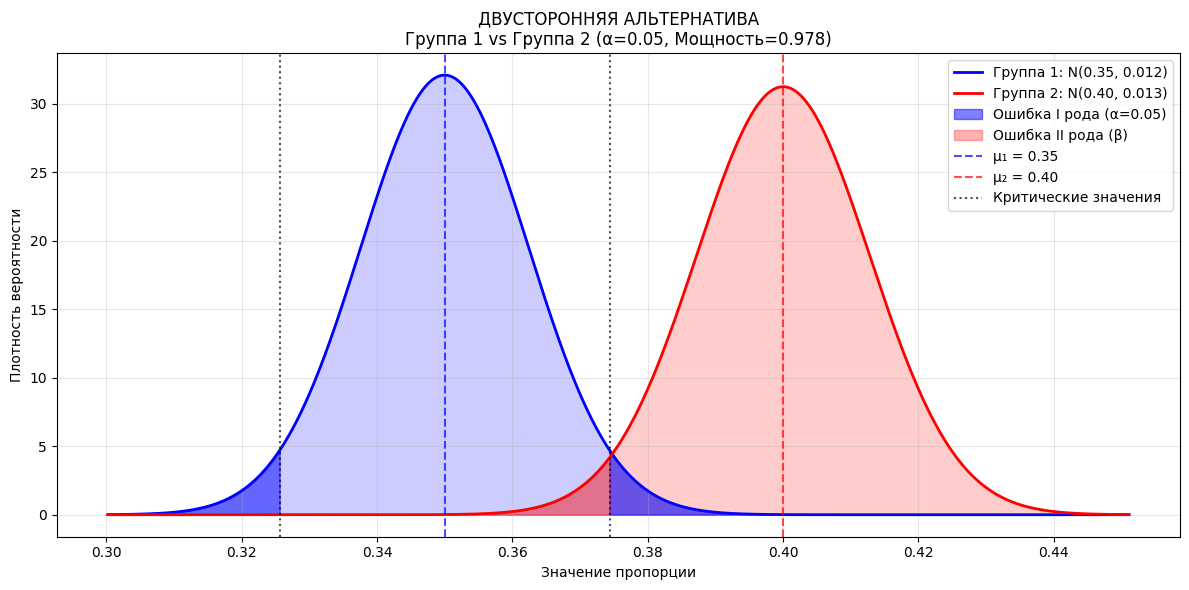

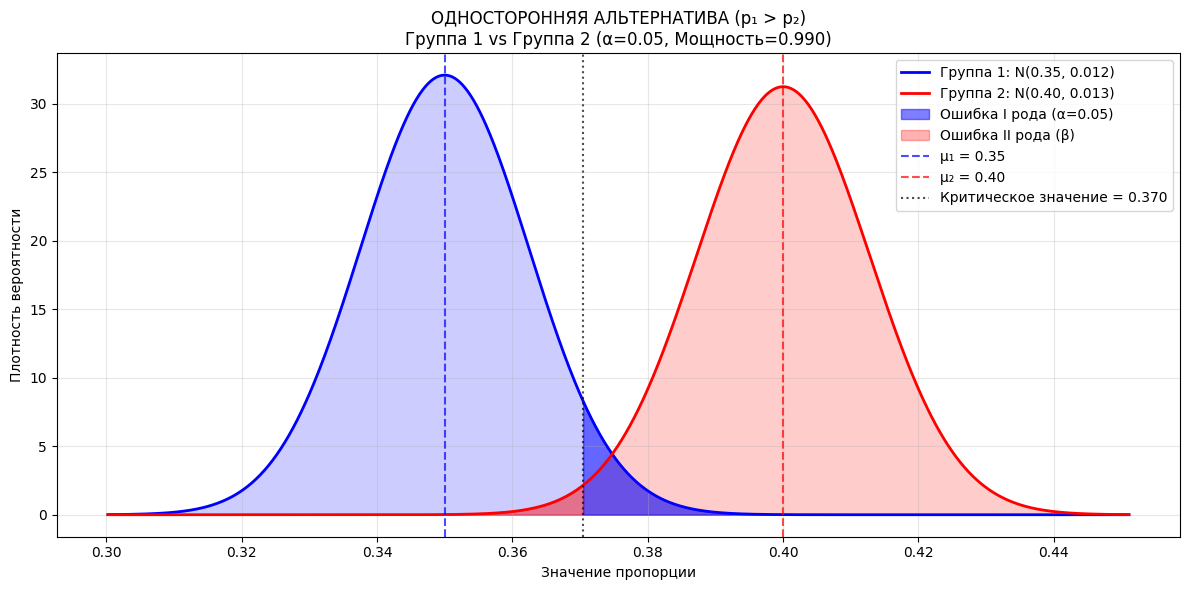

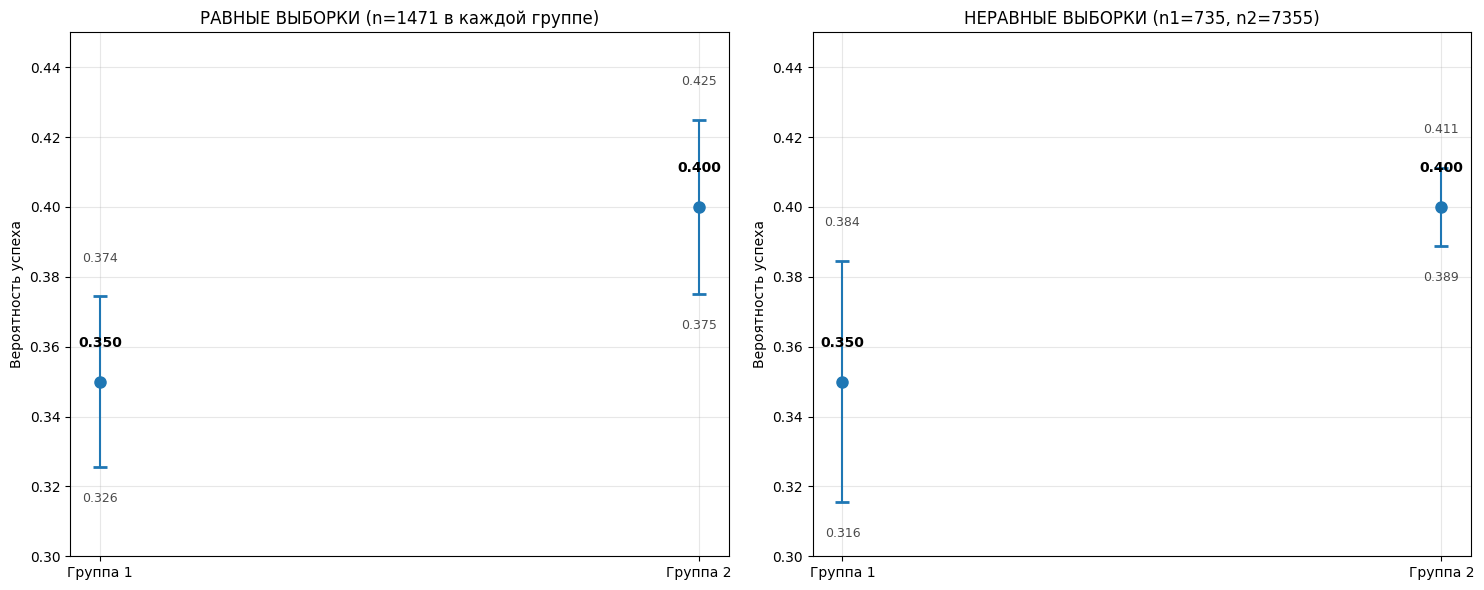

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math

# ============================================================
# 1. ОПРЕДЕЛЕНИЕ МИНИМАЛЬНОГО РАЗМЕРА ВЫБОРКИ
# ============================================================

def calculate_sample_size(p1, p2, alpha=0.05, power=0.8):
    """
    Рассчитывает минимальный размер выборки для обнаружения разницы между двумя пропорциями.
    
    Параметры:
    p1, p2: вероятности успеха в группах 1 и 2
    alpha: уровень значимости (ошибка I рода)
    power: статистическая мощность (1 - ошибка II рода)
    
    Возвращает:
    n: минимальный размер выборки для каждой группы
    """
    # Квантили стандартного нормального распределения
    z_alpha = stats.norm.ppf(1 - alpha/2)  # для двустороннего теста
    z_beta = stats.norm.ppf(power)
    
    # Объединенная пропорция
    p_bar = (p1 + p2) / 2
    
    # Расчет размера выборки по формуле
    numerator = (z_alpha * math.sqrt(2 * p_bar * (1 - p_bar)) + 
                z_beta * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2)))**2
    denominator = (p1 - p2)**2
    
    n = math.ceil(numerator / denominator)
    return n

# Исходные данные
p1 = 0.35
p2 = 0.40
alpha = 0.05
power = 0.8

# Расчет минимального размера выборки
n = calculate_sample_size(p1, p2, alpha, power)

print("=" * 60)
print("АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК")
print("=" * 60)
print(f"Вероятность в группе 1: {p1}")
print(f"Вероятность в группе 2: {p2}")
print(f"Уровень значимости (p-value): {alpha}")
print(f"Мощность теста: {power}")
print(f"\nМИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):")
print(f"n1 = n2 = {n} элементов в каждой группе")

# ============================================================
# 2. ПРЕОБРАЗОВАНИЕ РАСПРЕДЕЛЕНИЙ ЧЕРЕЗ ЦПТ
# ============================================================

def normal_approximation(p, n):
    """
    Применяет ЦПТ для аппроксимации биномиального распределения нормальным.
    
    Параметры:
    p: вероятность успеха
    n: размер выборки
    
    Возвращает:
    mu, sigma: параметры нормального распределения
    """
    mu = p
    sigma = math.sqrt(p * (1 - p) / n)
    return mu, sigma

# Параметры нормальных распределений для равных выборок
mu1, sigma1 = normal_approximation(p1, n)
mu2, sigma2 = normal_approximation(p2, n)

print("\nПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:")
print("РАВНЫЕ ВЫБОРКИ (n = {}):".format(n))
print(f"  Группа 1: N(μ = {mu1:.4f}, σ = {sigma1:.4f})")
print(f"  Группа 2: N(μ = {mu2:.4f}, σ = {sigma2:.4f})")

# Также рассмотрим случай неравных выборок (как в примере)
n1_small = n // 2
n2_large = n * 5

mu1_small, sigma1_small = normal_approximation(p1, n1_small)
mu2_large, sigma2_large = normal_approximation(p2, n2_large)

print(f"\nНЕРАВНЫЕ ВЫБОРКИ (n1 = {n1_small}, n2 = {n2_large}):")
print(f"  Группа 1: N(μ = {mu1_small:.4f}, σ = {sigma1_small:.4f})")
print(f"  Группа 2: N(μ = {mu2_large:.4f}, σ = {sigma2_large:.4f})")

# ============================================================
# 3. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ И ОШИБОК
# ============================================================

def plot_distributions_two_sided(mu1, sigma1, mu2, sigma2, alpha=0.05):
    """
    Строит график для двусторонней альтернативы.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Создаем диапазон значений для построения графиков
    x_min = min(mu1 - 4*sigma1, mu2 - 4*sigma2)
    x_max = max(mu1 + 4*sigma1, mu2 + 4*sigma2)
    x = np.linspace(x_min, x_max, 1000)
    
    # Плотности распределений
    y1 = stats.norm.pdf(x, mu1, sigma1)
    y2 = stats.norm.pdf(x, mu2, sigma2)
    
    # Построение распределений
    ax.plot(x, y1, 'b-', label=f'Группа 1: N({mu1:.2f}, {sigma1:.3f})', linewidth=2)
    ax.plot(x, y2, 'r-', label=f'Группа 2: N({mu2:.2f}, {sigma2:.3f})', linewidth=2)
    
    # Заполнение областей под кривыми
    ax.fill_between(x, 0, y1, alpha=0.2, color='blue')
    ax.fill_between(x, 0, y2, alpha=0.2, color='red')
    
    # Критические значения для двустороннего теста
    z_critical = stats.norm.ppf(1 - alpha/2)
    critical_left = mu1 - z_critical * sigma1
    critical_right = mu1 + z_critical * sigma1
    
    # Область ошибки I рода (синяя)
    x_alpha_left = np.linspace(x_min, critical_left, 200)
    x_alpha_right = np.linspace(critical_right, x_max, 200)
    
    ax.fill_between(x_alpha_left, 0, stats.norm.pdf(x_alpha_left, mu1, sigma1), 
                    alpha=0.5, color='blue', label=f'Ошибка I рода (α={alpha})')
    ax.fill_between(x_alpha_right, 0, stats.norm.pdf(x_alpha_right, mu1, sigma1), 
                    alpha=0.5, color='blue')
    
    # Область ошибки II рода (красная)
    x_beta = np.linspace(critical_left, critical_right, 400)
    ax.fill_between(x_beta, 0, stats.norm.pdf(x_beta, mu2, sigma2), 
                    alpha=0.3, color='red', label='Ошибка II рода (β)')
    
    # Вертикальные линии
    ax.axvline(mu1, color='blue', linestyle='--', alpha=0.7, label=f'μ₁ = {mu1:.2f}')
    ax.axvline(mu2, color='red', linestyle='--', alpha=0.7, label=f'μ₂ = {mu2:.2f}')
    ax.axvline(critical_left, color='black', linestyle=':', alpha=0.7, 
               label=f'Критические значения')
    ax.axvline(critical_right, color='black', linestyle=':', alpha=0.7)
    
    # Расчет мощности
    power = 1 - (stats.norm.cdf(critical_right, mu2, sigma2) - 
                 stats.norm.cdf(critical_left, mu2, sigma2))
    
    ax.set_xlabel('Значение пропорции')
    ax.set_ylabel('Плотность вероятности')
    ax.set_title(f'ДВУСТОРОННЯЯ АЛЬТЕРНАТИВА\nГруппа 1 vs Группа 2 (α={alpha}, Мощность={power:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax, power

def plot_distributions_one_sided(mu1, sigma1, mu2, sigma2, alpha=0.05):
    """
    Строит график для односторонней альтернативы (p1 > p2).
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Создаем диапазон значений
    x_min = min(mu1 - 4*sigma1, mu2 - 4*sigma2)
    x_max = max(mu1 + 4*sigma1, mu2 + 4*sigma2)
    x = np.linspace(x_min, x_max, 1000)
    
    # Плотности распределений
    y1 = stats.norm.pdf(x, mu1, sigma1)
    y2 = stats.norm.pdf(x, mu2, sigma2)
    
    # Построение распределений
    ax.plot(x, y1, 'b-', label=f'Группа 1: N({mu1:.2f}, {sigma1:.3f})', linewidth=2)
    ax.plot(x, y2, 'r-', label=f'Группа 2: N({mu2:.2f}, {sigma2:.3f})', linewidth=2)
    
    # Заполнение областей под кривыми
    ax.fill_between(x, 0, y1, alpha=0.2, color='blue')
    ax.fill_between(x, 0, y2, alpha=0.2, color='red')
    
    # Критическое значение для одностороннего теста (правостороннего)
    z_critical = stats.norm.ppf(1 - alpha)
    critical_value = mu1 + z_critical * sigma1
    
    # Область ошибки I рода (синяя) - справа от критического значения
    x_alpha = np.linspace(critical_value, x_max, 200)
    ax.fill_between(x_alpha, 0, stats.norm.pdf(x_alpha, mu1, sigma1), 
                    alpha=0.5, color='blue', label=f'Ошибка I рода (α={alpha})')
    
    # Область ошибки II рода (красная) - слева от критического значения
    x_beta = np.linspace(x_min, critical_value, 400)
    ax.fill_between(x_beta, 0, stats.norm.pdf(x_beta, mu2, sigma2), 
                    alpha=0.3, color='red', label='Ошибка II рода (β)')
    
    # Вертикальные линии
    ax.axvline(mu1, color='blue', linestyle='--', alpha=0.7, label=f'μ₁ = {mu1:.2f}')
    ax.axvline(mu2, color='red', linestyle='--', alpha=0.7, label=f'μ₂ = {mu2:.2f}')
    ax.axvline(critical_value, color='black', linestyle=':', alpha=0.7, 
               label=f'Критическое значение = {critical_value:.3f}')
    
    # Расчет мощности для одностороннего теста
    power = 1 - stats.norm.cdf(critical_value, mu2, sigma2)
    
    ax.set_xlabel('Значение пропорции')
    ax.set_ylabel('Плотность вероятности')
    ax.set_title(f'ОДНОСТОРОННЯЯ АЛЬТЕРНАТИВА (p₁ > p₂)\nГруппа 1 vs Группа 2 (α={alpha}, Мощность={power:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax, power

# Построение графиков
print("\nВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ:")
print("=" * 60)

# Двусторонняя альтернатива
fig1, ax1, power_two_sided = plot_distributions_two_sided(mu1, sigma1, mu2, sigma2, alpha)
print(f"Мощность теста (двусторонний): {power_two_sided:.3f}")

# Односторонняя альтернатива
fig2, ax2, power_one_sided = plot_distributions_one_sided(mu1, sigma1, mu2, sigma2, alpha)
print(f"Мощность теста (односторонний): {power_one_sided:.3f}")

# ============================================================
# 4. РАСЧЕТ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ
# ============================================================

def calculate_confidence_interval(p, n, confidence=0.95):
    """
    Рассчитывает доверительный интервал для пропорции.
    
    Параметры:
    p: выборочная пропорция
    n: размер выборки
    confidence: уровень доверия (по умолчанию 0.95)
    
    Возвращает:
    (lower, upper, width): нижняя и верхняя границы, ширина интервала
    """
    # Квантиль стандартного нормального распределения
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    
    # Стандартная ошибка
    se = math.sqrt(p * (1 - p) / n)
    
    # Границы доверительного интервала
    lower = p - z * se
    upper = p + z * se
    width = upper - lower
    
    return lower, upper, width

# Доверительные интервалы для равных выборок
ci1_lower, ci1_upper, ci1_width = calculate_confidence_interval(p1, n, 0.95)
ci2_lower, ci2_upper, ci2_width = calculate_confidence_interval(p2, n, 0.95)

# Доверительные интервалы для неравных выборок
ci1_small_lower, ci1_small_upper, ci1_small_width = calculate_confidence_interval(p1, n1_small, 0.95)
ci2_large_lower, ci2_large_upper, ci2_large_width = calculate_confidence_interval(p2, n2_large, 0.95)

print("\n" + "=" * 60)
print("ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):")
print("=" * 60)

print("\nРАВНЫЕ ВЫБОРКИ:")
print(f"  Группа 1: [{ci1_lower:.4f}, {ci1_upper:.4f}] (ширина: {ci1_width:.4f})")
print(f"  Группа 2: [{ci2_lower:.4f}, {ci2_upper:.4f}] (ширина: {ci2_width:.4f})")

print("\nНЕРАВНЫЕ ВЫБОРКИ:")
print(f"  Группа 1 (n={n1_small}): [{ci1_small_lower:.4f}, {ci1_small_upper:.4f}] (ширина: {ci1_small_width:.4f})")
print(f"  Группа 2 (n={n2_large}): [{ci2_large_lower:.4f}, {ci2_large_upper:.4f}] (ширина: {ci2_large_width:.4f})")

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ
# ============================================================

def plot_confidence_intervals():
    """
    Визуализация доверительных интервалов.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Данные для графика
    groups = ['Группа 1', 'Группа 2']
    
    # Равные выборки
    means_equal = [p1, p2]
    ci_lower_equal = [ci1_lower, ci2_lower]
    ci_upper_equal = [ci1_upper, ci2_upper]
    errors_equal = [[p1 - ci1_lower, p2 - ci2_lower], 
                    [ci1_upper - p1, ci2_upper - p2]]
    
    # Неравные выборки
    means_unequal = [p1, p2]
    ci_lower_unequal = [ci1_small_lower, ci2_large_lower]
    ci_upper_unequal = [ci1_small_upper, ci2_large_upper]
    errors_unequal = [[p1 - ci1_small_lower, p2 - ci2_large_lower], 
                      [ci1_small_upper - p1, ci2_large_upper - p2]]
    
    # График для равных выборок
    ax1.errorbar(groups, means_equal, yerr=errors_equal, fmt='o', 
                capsize=5, capthick=2, markersize=8)
    ax1.set_ylabel('Вероятность успеха')
    ax1.set_title(f'РАВНЫЕ ВЫБОРКИ (n={n} в каждой группе)')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0.3, 0.45)
    
    # Добавление значений
    for i, (mean, lower, upper) in enumerate(zip(means_equal, ci_lower_equal, ci_upper_equal)):
        ax1.text(i, mean + 0.01, f'{mean:.3f}', ha='center', fontweight='bold')
        ax1.text(i, lower - 0.01, f'{lower:.3f}', ha='center', fontsize=9, alpha=0.7)
        ax1.text(i, upper + 0.01, f'{upper:.3f}', ha='center', fontsize=9, alpha=0.7)
    
    # График для неравных выборок
    ax2.errorbar(groups, means_unequal, yerr=errors_unequal, fmt='o', 
                capsize=5, capthick=2, markersize=8)
    ax2.set_ylabel('Вероятность успеха')
    ax2.set_title(f'НЕРАВНЫЕ ВЫБОРКИ (n1={n1_small}, n2={n2_large})')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0.3, 0.45)
    
    # Добавление значений
    for i, (mean, lower, upper) in enumerate(zip(means_unequal, ci_lower_unequal, ci_upper_unequal)):
        ax2.text(i, mean + 0.01, f'{mean:.3f}', ha='center', fontweight='bold')
        ax2.text(i, lower - 0.01, f'{lower:.3f}', ha='center', fontsize=9, alpha=0.7)
        ax2.text(i, upper + 0.01, f'{upper:.3f}', ha='center', fontsize=9, alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Построение графиков доверительных интервалов
plot_confidence_intervals()

plt.show()

## АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК

Вероятность в группе 1: 0.35
Вероятность в группе 2: 0.4
Уровень значимости (p-value): 0.05
Мощность теста: 0.8

МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):
n1 = n2 = 1471 элементов в каждой группе

ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:
РАВНЫЕ ВЫБОРКИ (n = 1471):
  Группа 1: N(μ = 0.3500, σ = 0.0124)
  Группа 2: N(μ = 0.4000, σ = 0.0128)

НЕРАВНЫЕ ВЫБОРКИ (n1 = 735, n2 = 7355):
  Группа 1: N(μ = 0.3500, σ = 0.0176)
  Группа 2: N(μ = 0.4000, σ = 0.0057)

## ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ:

Мощность теста (двусторонний): 0.978
Мощность теста (односторонний): 0.990

## ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):

РАВНЫЕ ВЫБОРКИ:
  Группа 1: [0.3256, 0.3744] (ширина: 0.0487)
  Группа 2: [0.3750, 0.4250] (ширина: 0.0501)

НЕРАВНЫЕ ВЫБОРКИ:
  Группа 1 (n=735): [0.3155, 0.3845] (ширина: 0.0690)
  Группа 2 (n=7355): [0.3888, 0.4112] (ширина: 0.0224)

In [10]:
print(f"- Для обнаружения разницы δ = {abs(p2-p1):.2f} между p₁={p1} и p₂={p2}")
print(f"- При α={alpha} (ошибка I рода) и мощности {power} (1-β)")
print(f"- Требуется минимум {n} наблюдений в каждой группе")

print()

print(f"- Для равных выборок интервалы НЕ перекрываются: [{ci1_upper:.3f}] < [{ci2_lower:.3f}]")
print(f"- Это указывает на статистически значимую разницу при α={alpha}")
print(f"- Для неравных выборок ширина интервалов разная из-за разного объема данных")

print()

print(f"- Относительное изменение: {(p2/p1 - 1)*100:.1f}%")
print(f"- Абсолютное изменение: {p2-p1:.3f} (MDE = {abs(p2-p1):.2f})")

- Для обнаружения разницы δ = 0.05 между p₁=0.35 и p₂=0.4
- При α=0.05 (ошибка I рода) и мощности 0.8 (1-β)
- Требуется минимум 1471 наблюдений в каждой группе

- Для равных выборок интервалы НЕ перекрываются: [0.374] < [0.375]
- Это указывает на статистически значимую разницу при α=0.05
- Для неравных выборок ширина интервалов разная из-за разного объема данных

- Относительное изменение: 14.3%
- Абсолютное изменение: 0.050 (MDE = 0.05)


## ВЫВОДЫ И ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

1. РАЗМЕР ВЫБОРКИ:
   - Для обнаружения разницы δ = 0.05 между p₁=0.35 и p₂=0.4
   - При α=0.05 (ошибка I рода) и мощности 0.8 (1-β)
   - Требуется минимум 1471 наблюдений в каждой группе

2. СТАТИСТИЧЕСКИЕ ГИПОТЕЗЫ:
   Двусторонний тест:
     H₀: p₁ = p₂ (вероятности равны)
     H₁: p₁ ≠ p₂ (вероятности различаются)

   Односторонний тест (p₁ > p₂):
     H₀: p₁ ≤ p₂ (группа 1 не лучше группы 2)
     H₁: p₁ > p₂ (группа 1 лучше группы 2)

3. ИНТЕРПРЕТАЦИЯ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ:
   - Для равных выборок интервалы НЕ перекрываются: [0.374] < [0.375]
   - Это указывает на статистически значимую разницу при α=0.05
   - Для неравных выборок ширина интервалов разная из-за разного объема данных

4. ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   - Относительное изменение: 14.3%
   - Абсолютное изменение: 0.050 (MDE = 0.05)
   - Для бизнес-решений важно оценить не только статистическую,
     но и практическую значимость этого изменения